# Notebook 1 — Preprocessing and EDA

Takes the label files notebook 0 wrote into `own_footprints/` and turns them
into model-ready image patches. It:

1. **Downloads Sentinel imagery once** per city, straight to Drive: one
   pre-war composite for the city, and one post composite per date.
2. **Cuts one patch per building** into memory-mapped arrays, aligned to a
   single canonical building table, so notebooks 2 and 3 need no Earth Engine.
3. **Explores Gaza** (Section 5) — damage over time, class balance, and what
   the radar signal actually looks like, including across the temporal
   offsets.
4. **Profiles the holdout cities** (Section 6) against Gaza, so their
   prevalence, building stock and signal strength are known before the final
   evaluation rather than after it.

All settings describing the files on disk live in `PREP` in `pipeline.py`.
File names encode those settings, so changing one forces new files instead of
silently reusing old ones. **Which cities and dates get processed is decided
entirely by `CITY_REGISTRY`**, not by what happens to sit in
`own_footprints/` — notebook 0 may deliberately have written more dates than
we want to model, and Section 1 prints anything it finds on disk but is not
registered.

---

## What changed in this version

**Five cities, not one.** Gaza is the only `role: "develop"` city — the one
notebook 2 carves into train / stack / val / test latitude bands, so it has a
test set *of its own*. Raqqa, Mosul, Chernihiv and Rubizhne are
`role: "holdout"`: absent from every one of those bands, including Gaza's
test band, until the final comparison.

The two are different measurements and the word "test" covers both, which is
why the roles are named `develop`/`holdout` rather than `train`/`test`.
Gaza's test band measures generalisation to unseen **ground** in a familiar
city; the holdout cities measure generalisation to a whole new **city** —
different sensor geometry, building stock and conflict.
`development_cities()`, `held_out_cities()` and `check_split_holdout()` in
`pipeline.py` make the distinction checkable in code rather than by eye.

**Nothing already on disk is downloaded again.** Gaza's composites and patch
arrays were produced by an earlier run and cost hours of Earth Engine time.
Every exporter and the patch cutter already skip existing outputs; Section 1b
now shows that up front, so you can confirm before starting that a run will
only touch the new cities. The export and cut loops also catch per-city
failures instead of aborting, so one city's Earth Engine hiccup no longer
discards the work of the ones that succeeded.

**Unusable assessment dates are refused, not exported.** A date whose post
window starts before `war_start` would be compared against a "pre-war"
baseline recorded *after* the damage, and Sentinel-1 barely exists before
October 2014. `check_city_windows()` catches both. This is not hypothetical:
four of Raqqa's five UNOSAT assessments fail it, which is why only 20171021
is registered.

**Pre and post imagery are stored separately.** The pre-war composite is
identical for every assessment date — only the post window moves — so it is
exported and cut **once per city** rather than once per date. That halves the
storage for the labelled dates and, more importantly, makes each extra time
point cost two bands instead of four.

**Every array is aligned to one canonical building table.** `{city}_…
_buildings.parquet` holds the buildings present at every assessment date, in
a fixed order, with one label column per date. Every patch array has one row
per table row plus a `valid` mask saying whether that row's patch is usable.
Row alignment across dates is therefore positional and free — a building
missing at one date becomes a masked row, never a shifted index.

**Unlabelled temporal offsets are exported too.** `PREP["temporal"]` adds
post composites at ±12 and ±24 days around each assessment date. They carry
no labels and never enter CNN training; they exist so notebook 2 can run the
trained CNN over the same buildings at neighbouring dates and hand the
resulting score *series* to the second-stage model. Genuine damage appears
once and persists, speckle flickers — that contrast is the whole point.

12 days is not arbitrary: it is Sentinel-1's orbital repeat. Since S1B failed
in December 2021 a given relative orbit passes every 12 days, so 12 is the
finest grid on which consecutive points contain a different acquisition.

## 1. Setup

Check these in `pipeline.py` before running:

```python
DATA_DIR = os.path.join(BASE, "Data", "own_footprints")   # not one_month
PREP["imagery"]["post_direction"] = "backward"
PREP["temporal"] = {"enabled": True, "step_days": 12,
                    "n_before": 2, "n_after": 2, "window_days": None}
```

**Why backward.** Gaza's assessments are 19 to 64 days apart, and some gaps
are shorter than a month. A *forward* one-month window starting at an
assessment would run past the next one, so it would contain damage the
earlier label says has not happened yet, and the model would be punished for
seeing it. Looking backward from each assessment date avoids that.

**Why `window_days` is separate from `step_days`.** With the default 1-month
window a 12-day shift swaps roughly one scene in three, so neighbouring
points are correlated but de-speckled. Setting `window_days = 12` makes each
point a single acquisition: fully distinct, but carrying full speckle. Which
is better is an empirical question, and the XGB feature importances in
notebook 2 answer it.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q geedim geemap

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.9 MB/s eta 0:00:00


In [ ]:
import sys
BASE = "/content/drive/MyDrive/War-Damage-Detection"   # adjust if needed
sys.path.append(BASE)

import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd

from pipeline import (PREP, CITY_REGISTRY, DATA_DIR, PWTT_DIR, PROCESSED_DIR,
                      RASTER_DIR, S1_CHANNELS, S2_CHANNELS, S1_EARLIEST,
                      load_labels, list_label_dates, sample_buildings,
                      stored_channels, prep_tag,
                      pre_raster_path, post_raster_path, export_meta_path,
                      read_export_meta, write_export_meta,
                      buildings_path, pre_patch_paths, post_patch_paths,
                      open_patch_writer, temporal_offsets, offset_dates,
                      temporal_window_days, post_jobs, shift_date,
                      load_city, post_arrays, usable_mask,
                      summarize_processed, split_legacy_rasters,
                      city_role, development_cities, held_out_cities,
                      check_city_windows, inventory, inventory_summary)

print("label folder: ", DATA_DIR)
print("raster folder:", RASTER_DIR)
print("patch folder: ", PROCESSED_DIR)
print(f"\npatch tag: {prep_tag()}")
print("preprocessing settings:")
for k, v in PREP.items():
    print(f"  {k}: {v}")

print(f"\ntemporal offsets (days): {temporal_offsets()}")
print(f"develop (split into bands in nb 2): {development_cities()}")
print(f"holdout (absent from every band):   {held_out_cities()}")

print("\nregistered cities and dates:")
for city, info in CITY_REGISTRY.items():
    on_disk = list_label_dates(city)
    missing = [d for d in info["label_dates"] if d not in on_disk]
    extra = [d for d in on_disk if d not in info["label_dates"]]
    print(f"  {city} [{city_role(city)}]: {len(info['label_dates'])} dates, "
          f"war start {info['war_start']}")
    print(f"     using: {info['label_dates']}")
    if missing:
        print(f"     MISSING from {DATA_DIR}: {missing}")
    if extra:
        # not a problem: CITY_REGISTRY is the authority on which dates we
        # model, and notebook 0 may deliberately have written more
        print(f"     also on disk, not registered: {extra}")

    # Refuse early rather than exporting imagery that cannot mean anything.
    for date, reason in check_city_windows(city):
        print(f"     UNUSABLE {f'date {date}' if date else 'city'}: {reason}")

    jobs = post_jobs(city)
    lab = [d for d, w, is_lab in jobs if is_lab]
    off = [d for d, w, is_lab in jobs if not is_lab]
    print(f"     post composites needed: {len(jobs)} "
          f"({len(lab)} labelled + {len(off)} unlabelled offsets)")
    print(f"     offsets: {off}")

### 1b. What is already on disk

Gaza was fully exported and cut by an earlier run, and re-downloading it would
cost hours of Earth Engine time for files that already exist. Every export and
cut function below already skips work whose output file is present, so nothing
here is required for correctness — this cell just makes that visible **before**
you start, so you can confirm the run will only touch the new cities.

`to_export` and `to_cut` are the counts that actually cost time. If Gaza shows
`0 / 0`, the cells below will pass straight over it.

In [ ]:
# Preflight: what exists, and what this run would actually download.
overview = inventory_summary()
print(overview.to_string(index=False))

todo = overview[(overview["to_export"] > 0) | (overview["to_cut"] > 0)]
done = overview[(overview["to_export"] == 0) & (overview["to_cut"] == 0)]

print(f"\nalready complete, will be skipped: "
      f"{list(done['city']) if len(done) else 'none'}")
if len(todo):
    print(f"work to do: {overview['to_export'].sum()} composites to export, "
          f"{overview['to_cut'].sum()} patch arrays to cut, for "
          f"{list(todo['city'])}")
    # a 2-band S1 composite over a small city is ~10-125 MB; the patch array
    # is the bigger cost and scales with the building count
    print("\nper city, the missing pieces:")
    for city in todo["city"]:
        inv = inventory(city)
        miss = inv[~inv["raster"] | ~inv["patches"]]
        print(f"\n{city} [{city_role(city)}]")
        print(miss[["kind", "date", "sensor", "raster", "patches"]]
              .to_string(index=False))
else:
    print("everything is already on disk - the export and cut cells are no-ops.")

## 2. Earth Engine export

**One pre-war composite per city.** Twelve months ending at `war_start`,
exported once and reused by every date and every temporal offset.

**One post composite per date**, including the unlabelled offset dates.

**The relative orbit is pinned per city.** Mixing orbits injects viewing-angle
differences that look like change but are not damage. When pre and post lived
in a single export the orbit could be chosen per file; now that they are
separate files it has to be decided once for the city and written to
`rasters/{city}_export.json`, along with the bounding box, so every raster
covers the same ground on the same grid.

The orbit is chosen by *measured coverage of the city* across the pre window
and all labelled post windows, not by image count, since a scene clipping one
corner counts the same as one covering it fully.

Exports land directly on Drive and re-running costs nothing once the files
exist. Budget roughly **125 MB per 2-band composite** for Gaza: about 2 GB for
one pre plus fifteen post composites.

In [ ]:
# S1_EARLIEST now lives in pipeline.py, so check_city_windows() and the
# orbit chooser below agree on the same cutoff.


def _init_ee():
    import ee
    project = PREP["imagery"]["gee_project"]
    try:
        ee.Initialize(project=project)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=project)
    return ee


def _iso(date):
    """'20240503' -> '2024-05-03'."""
    return f"{date[:4]}-{date[4:6]}-{date[6:8]}"


def pre_window(city):
    """(start, end) of the pre-war baseline. The same for every date."""
    im = PREP["imagery"]
    war = pd.Timestamp(CITY_REGISTRY[city]["war_start"])
    return ((war - pd.DateOffset(months=im["pre_months"])).strftime("%Y-%m-%d"),
            war.strftime("%Y-%m-%d"))


def post_window(date, window_days=None):
    """(start, end) of one post composite.

    window_days overrides post_months, which is how the temporal offsets can
    use a different (usually shorter) window than the labelled dates.
    """
    im = PREP["imagery"]
    d = pd.Timestamp(_iso(date))
    length = (pd.Timedelta(days=int(window_days)) if window_days
              else pd.DateOffset(months=im["post_months"]))
    a, b = ((d, d + length) if im["post_direction"] == "forward"
            else (d - length, d))
    return a.strftime("%Y-%m-%d"), b.strftime("%Y-%m-%d")


def city_bbox(city):
    """Export area, decided ONCE per city and cached.

    Every raster of a city must cover the same ground: if the pre raster and
    a post raster had different extents, a building could sit comfortably
    inside one and off the edge of the other, and the two patch arrays would
    disagree about which rows are usable.
    """
    meta = read_export_meta(city)
    if "bbox" in meta:
        return meta["bbox"]
    bounds = []
    for date in CITY_REGISTRY[city]["label_dates"]:
        bounds.append(load_labels(city, date).total_bounds)
    b = np.array(bounds)
    pad = PREP["imagery"]["aoi_buffer_deg"]
    bbox = [float(b[:, 0].min() - pad), float(b[:, 1].min() - pad),
            float(b[:, 2].max() + pad), float(b[:, 3].max() + pad)]
    write_export_meta(city, bbox=bbox)
    print(f"  {city} bbox: {[round(v, 4) for v in bbox]}")
    return bbox

In [4]:
def _s1_collection(ee, aoi):
    """Sentinel-1 IW, VV+VH, with swath-edge pixels masked out.

    Pixels outside the radar swath are minus infinity in dB (log of zero).
    Mask them before compositing, or one pixel poisons the median.
    """
    def mask_edges(img):
        valid = img.select("VV").gt(-35).And(img.select("VH").gt(-35))
        return img.updateMask(valid)

    return (ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi)
            .filter(ee.Filter.eq("instrumentMode", "IW"))
            .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
            .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
            .select(["VV", "VH"]).map(mask_edges))


def choose_orbit(city, force=False):
    """Pick one relative orbit for the whole city and remember it.

    Scored by the WORST coverage across the pre window and every labelled
    post window, so the winner is an orbit that sees the city properly at
    every date rather than one that happens to have many scenes.
    """
    meta = read_export_meta(city)
    if "orbit" in meta and not force:
        return meta["orbit"]

    ee = _init_ee()
    aoi = ee.Geometry.Rectangle(city_bbox(city))
    s1 = _s1_collection(ee, aoi)

    windows = {"pre": pre_window(city)}
    for date in CITY_REGISTRY[city]["label_dates"]:
        windows[date] = post_window(date)

    if windows["pre"][0] < S1_EARLIEST:
        print(f"  WARNING: the pre window starts before {S1_EARLIEST}, where "
              f"Sentinel-1 has no data. Shorten pre_months or move war_start.")

    counts = {}
    for name, (a, b) in windows.items():
        h = (s1.filterDate(a, b)
               .aggregate_histogram("relativeOrbitNumber_start").getInfo())
        counts[name] = {int(float(k)): int(v) for k, v in h.items()}

    shared = set.intersection(*[set(c) for c in counts.values()])
    if not shared:
        raise RuntimeError(f"{city}: no single orbit covers every window. {counts}")

    def coverage(a, b, orbit):
        c = s1.filterDate(a, b).filter(
            ee.Filter.eq("relativeOrbitNumber_start", orbit))
        m = c.select("VV").count().gt(0).unmask(0)
        return m.reduceRegion(ee.Reducer.mean(), aoi, 200, maxPixels=1e9).get("VV")

    cov = ee.Dictionary({
        f"{o}|{name}": coverage(a, b, o)
        for o in shared for name, (a, b) in windows.items()}).getInfo()

    scored = {o: min((cov[f"{o}|{n}"] or 0) for n in windows) for o in shared}
    best = max(scored, key=lambda o: (scored[o], min(counts[n][o] for n in windows)))
    for o in sorted(shared):
        per = "  ".join(f"{n}:{counts[n][o]:2d}/{cov[f'{o}|{n}'] or 0:.2f}"
                        for n in windows)
        print(f"  orbit {o}: {per}")
    print(f"  {city}: using orbit {best}, worst-case coverage {scored[best]:.2f}")
    if scored[best] < PREP["imagery"]["min_aoi_coverage"]:
        print(f"  WARNING: the best orbit covers only {scored[best]*100:.0f} percent "
              f"of the city in its worst window; much of that export is nodata.")
    write_export_meta(city, orbit=int(best), orbit_coverage=float(scored[best]))
    return int(best)

In [5]:
def _download(ee, image, aoi, out):
    import geemap
    tmp = out + ".part"
    geemap.download_ee_image(image, tmp, region=aoi,
                             scale=PREP["imagery"]["scale"], crs="EPSG:4326")
    os.replace(tmp, out)          # rename last, so a killed cell leaves no
    print(f"  exported {os.path.basename(out)}")   # half-file that looks done


def export_s1_pre(city):
    out = pre_raster_path(city, "s1")
    if os.path.exists(out):
        print(f"  {os.path.basename(out)} exists, skipping")
        return out
    ee = _init_ee()
    aoi = ee.Geometry.Rectangle(city_bbox(city))
    orbit = choose_orbit(city)
    a, b = pre_window(city)
    col = (_s1_collection(ee, aoi).filterDate(a, b)
           .filter(ee.Filter.eq("relativeOrbitNumber_start", orbit)))
    n = col.size().getInfo()
    print(f"  {city} pre-war {a} to {b}: {n} scenes on orbit {orbit}")
    img = col.median().rename(["pre_VV", "pre_VH"]).clip(aoi).toFloat()
    _download(ee, img, aoi, out)
    return out


def export_s1_post(city, date, window_days=None):
    out = post_raster_path(city, date, "s1", window_days)
    if os.path.exists(out):
        print(f"  {os.path.basename(out)} exists, skipping")
        return out
    ee = _init_ee()
    aoi = ee.Geometry.Rectangle(city_bbox(city))
    orbit = choose_orbit(city)
    a, b = post_window(date, window_days)
    col = (_s1_collection(ee, aoi).filterDate(a, b)
           .filter(ee.Filter.eq("relativeOrbitNumber_start", orbit)))
    n = col.size().getInfo()
    print(f"  {city} {date} post {a} to {b}: {n} scenes on orbit {orbit}")
    if n == 0:
        raise RuntimeError(
            f"{city} {date}: no scenes on orbit {orbit} in {a}..{b}. The "
            f"window is shorter than the 12-day repeat, or the orbit had an "
            f"outage. Widen PREP['temporal']['window_days'].")
    if n == 1:
        print("  NOTE: a single scene, so there is no median and this point "
              "carries full speckle. Expected when window_days = 12.")
    img = col.median().rename(["post_VV", "post_VH"]).clip(aoi).toFloat()
    _download(ee, img, aoi, out)
    return out

In [6]:
def _s2_composite(ee, aoi, a, b, bands):
    im = PREP["imagery"]

    def mask_scl(img):        # surface reflectance cloud mask
        scl = img.select("SCL")
        bad = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10))
        return img.updateMask(bad.Not())

    def mask_qa60(img):       # top-of-atmosphere cloud mask
        qa = img.select("QA60")
        clear = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        return img.updateMask(clear)

    for cid, fn, level in [("COPERNICUS/S2_SR_HARMONIZED", mask_scl, "SR"),
                           ("COPERNICUS/S2_HARMONIZED", mask_qa60, "TOA")]:
        col = (ee.ImageCollection(cid).filterBounds(aoi).filterDate(a, b)
               .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", im["s2_max_cloud"])))
        n = col.size().getInfo()
        if n > 0:
            return col.map(fn).select(bands).median(), n, level
    return None, 0, "none"


S2_BANDS = ["B2", "B3", "B4", "B8"]


def export_s2_pre(city):
    out = pre_raster_path(city, "s2")
    if os.path.exists(out):
        print(f"  {os.path.basename(out)} exists, skipping")
        return out
    ee = _init_ee()
    aoi = ee.Geometry.Rectangle(city_bbox(city))
    a, b = pre_window(city)
    img, n, lvl = _s2_composite(ee, aoi, a, b, S2_BANDS)
    print(f"  {city} pre-war Sentinel-2: {n} scenes ({lvl})")
    if n == 0:
        raise RuntimeError(f"{city}: no usable Sentinel-2 in the pre window.")
    write_export_meta(city, s2_pre_level=lvl)
    img = img.rename([f"pre_{x}" for x in S2_BANDS]).clip(aoi).toFloat()
    _download(ee, img, aoi, out)
    return out


def export_s2_post(city, date, window_days=None):
    out = post_raster_path(city, date, "s2", window_days)
    if os.path.exists(out):
        print(f"  {os.path.basename(out)} exists, skipping")
        return out
    ee = _init_ee()
    aoi = ee.Geometry.Rectangle(city_bbox(city))
    a, b = post_window(date, window_days)
    img, n, lvl = _s2_composite(ee, aoi, a, b, S2_BANDS)
    print(f"  {city} {date} Sentinel-2: {n} scenes ({lvl})")
    if n == 0:
        raise RuntimeError(f"{city} {date}: no usable Sentinel-2 in the post window.")
    if lvl != read_export_meta(city).get("s2_pre_level", lvl):
        print("  WARNING: pre and post use different processing levels (SR vs "
              "TOA), so their difference is contaminated by the atmosphere.")
    img = img.rename([f"post_{x}" for x in S2_BANDS]).clip(aoi).toFloat()
    _download(ee, img, aoi, out)
    return out


PRE_EXPORTERS = {"s1": export_s1_pre, "s2": export_s2_pre}
POST_EXPORTERS = {"s1": export_s1_post, "s2": export_s2_post}

### 2b. Reuse the rasters you already exported

If you ran the previous version of this notebook you already have combined
4-band GeoTIFFs on Drive. Their pre bands *are* the city's pre-war composite
and their post bands *are* that date's post composite, so they can be split
locally instead of re-downloaded. Only the new temporal offset dates then
need Earth Engine.

This is safe to run on a clean Drive too — it just reports that there is
nothing to split.

In [7]:
for city in CITY_REGISTRY:
    print(city)
    split_legacy_rasters(city)

Gaza
  wrote gaza_s1_pre12m.tif
  wrote gaza_20240503_s1_post_backward1m.tif
  wrote gaza_20240706_s1_post_backward1m.tif
  wrote gaza_20240906_s1_post_backward1m.tif


In [ ]:
# The exports. Labelled dates first, then the unlabelled temporal offsets, so
# an interrupted run still leaves you with everything the CNN needs.
#
# Two changes now that there are five cities rather than one:
#
#   - a city whose windows fail check_city_windows() is skipped outright,
#     rather than exporting imagery that cannot support a pre/post comparison;
#   - a failure in one city is caught and reported instead of aborting the
#     loop, so a single Earth Engine hiccup on the fourth city does not throw
#     away the three that already succeeded. Re-running resumes where it
#     stopped, since every exporter skips files that exist.

failures = {}
for city, info in CITY_REGISTRY.items():
    print(f"\n=== {city} [{city_role(city)}] ===")

    bad = [f"{d}: {why}" for d, why in check_city_windows(city) if d]
    if bad:
        print("  SKIPPED, unusable assessment dates:")
        for b in bad:
            print(f"    {b}")
        failures[city] = "unusable windows"
        continue

    try:
        city_bbox(city)
        for sensor in PREP["sensors"]:
            PRE_EXPORTERS[sensor](city)
        for date, window_days, is_labelled in post_jobs(city):
            kind = "labelled" if is_labelled else "offset"
            print(f"  -- {date} ({kind})")
            for sensor in PREP["sensors"]:
                POST_EXPORTERS[sensor](city, date, window_days)
    except Exception as e:
        print(f"  FAILED: {type(e).__name__}: {e}")
        failures[city] = f"{type(e).__name__}: {e}"

print("\n" + "=" * 60)
if failures:
    print("cities needing attention:")
    for city, why in failures.items():
        print(f"  {city}: {why}")
else:
    print("every registered city exported.")
print("\nafter this run:")
print(inventory_summary().to_string(index=False))

## 3. The canonical building table

One table per city, holding the buildings that exist at **every** assessment
date, sorted by `system:index` and sampled by id rather than by row position.
Every patch array is aligned to it positionally, so joining a pre patch to a
post patch, or a May score to a July score, needs no id matching at all.

Columns: `system:index`, geometry, `area`, coordinates (`lon`/`lat` and
`x_m`/`y_m` in metres for the neighbour searches), and one `class_{date}`
column per assessment — plus `max_change_{date}` and `severity_{date}` where
the label files carry them.

Holding the label matrix in one table is also what makes multi-date
validation cheap in notebook 2: the same building at three dates is three
rows referring to the same patch geometry and three different post arrays.

In [ ]:
def build_building_table(city, force=False):
    path = buildings_path(city)
    if os.path.exists(path) and not force:
        tab = gpd.read_parquet(path)
        print(f"{city}: table exists, {len(tab):,} buildings")
        return tab

    dates = CITY_REGISTRY[city]["label_dates"]
    frames = {}
    for d in dates:
        g = load_labels(city, d)
        frames[d] = g[~g["system:index"].duplicated()].set_index("system:index")
        print(f"  {city} {d}: {len(frames[d]):,} rows, "
              f"{frames[d]['class'].mean()*100:.1f} percent damaged")

    ids = set.intersection(*[set(f.index) for f in frames.values()])
    print(f"  present at all {len(dates)} dates: {len(ids):,}")

    base = frames[dates[-1]].loc[sorted(ids)].reset_index()
    base = sample_buildings(base, PREP["n_sample"], PREP["seed"])
    base = base.sort_values("system:index").reset_index(drop=True)

    keep = ["system:index", "geometry"] + [c for c in ["area"] if c in base]
    # a GeoDataFrame, not a plain frame: parquet needs the geometry metadata
    # for notebook 3 to read the footprints back as polygons
    tab = gpd.GeoDataFrame(base[keep].copy(), geometry="geometry", crs="EPSG:4326")
    cen = base["centroid"]
    merc = cen.to_crs(3857)
    tab["lon"] = cen.apply(lambda p: p.x).to_numpy(float)
    tab["lat"] = cen.apply(lambda p: p.y).to_numpy(float)
    tab["x_m"] = merc.apply(lambda p: p.x).to_numpy(float)
    tab["y_m"] = merc.apply(lambda p: p.y).to_numpy(float)

    for d in dates:
        f = frames[d]
        tab[f"class_{d}"] = tab["system:index"].map(f["class"]).to_numpy(int)
        for extra in ["max_change", "severity", "confidence"]:
            if extra in f.columns:
                tab[f"{extra}_{d}"] = tab["system:index"].map(f[extra]).to_numpy(float)

    tab.to_parquet(path)
    print(f"  saved {os.path.basename(path)}: {len(tab):,} buildings, "
          f"{len(dates)} label columns")
    return tab


# Same resilience as the export loop: a city whose label CSVs are missing
# should not stop the others from being built.
tables = {}
for city in CITY_REGISTRY:
    try:
        tables[city] = build_building_table(city)
    except Exception as e:
        print(f"{city}: FAILED - {type(e).__name__}: {e}")

print(f"\nbuilt tables for: {list(tables)}")
print(pd.DataFrame([
    {"city": c, "role": city_role(c), "buildings": len(t),
     "label_cols": sum(k.startswith("class_") for k in t.columns)}
    for c, t in tables.items()]).to_string(index=False))

## 4. Cut patches

One patch per building per raster, centred on its centroid. A row is written
for **every** building in the table whether or not its patch is usable, and a
separate boolean `valid` array records which rows actually hold pixels. That
is what keeps the arrays positionally aligned: a building that falls off the
edge of one date's raster becomes a masked row there rather than a missing
row that shifts everything after it.

(Radar nodata is *minus infinity* in dB, not NaN — hence the `np.isfinite`
check rather than `np.isnan`.)

Patches are written straight into a memory-mapped `.npy` in chunks, so the
full stack never exists in RAM. They are stored as float16: backscatter in dB
spans about −35 to +5, where float16 resolves ~0.01 dB, far finer than radar
speckle. Uncompressed and in their own file, so notebook 2 can memory-map
them — a compressed `.npz` member has no fixed position on disk and would
have to be decompressed whole.

In [ ]:
CHUNK = 4096   # rows buffered before writing to the memory map


def _corners(paths, tab, patch):
    """Per-raster top-left patch corners, plus which buildings fit."""
    half = patch // 2
    lons, lats = tab["lon"].to_numpy(float), tab["lat"].to_numpy(float)
    out = []
    for p in paths:
        with rasterio.open(p) as src:
            cols, rows = (~src.transform) * (lons, lats)
            r0 = np.round(rows).astype(int) - half
            c0 = np.round(cols).astype(int) - half
            inside = ((r0 >= 0) & (c0 >= 0) &
                      (r0 + patch <= src.height) & (c0 + patch <= src.width))
            out.append((p, r0, c0, inside, src.count))
    return out


def cut_phase(city, tab, phase, date=None, window_days=None, force=False):
    """Write the pre (or one post) patch array plus its valid mask."""
    patch = PREP["patch_size"]
    if phase == "pre":
        paths = [pre_raster_path(city, s) for s in PREP["sensors"]]
        x_path, v_path = pre_patch_paths(city)
    else:
        paths = [post_raster_path(city, date, s, window_days)
                 for s in PREP["sensors"]]
        x_path, v_path = post_patch_paths(city, date, window_days)

    label = f"{city} {phase}" + (f" {date}" if date else "")
    if os.path.exists(x_path) and os.path.exists(v_path) and not force:
        print(f"  {label}: already cut")
        return
    for p in paths:
        if not os.path.exists(p):
            raise FileNotFoundError(f"{p} missing - run the export cell first")

    info = _corners(paths, tab, patch)
    n = len(tab)
    n_ch = sum(c for *_, c in info)
    fits = np.logical_and.reduce([i[3] for i in info])

    arrays = []
    for p, *_ in info:
        with rasterio.open(p) as src:
            arrays.append(src.read().astype(np.float32))

    tmp = x_path + ".part"
    out = open_patch_writer(tmp, n, n_ch, patch)
    valid = np.zeros(n, bool)
    buf = np.zeros((CHUNK, n_ch, patch, patch), np.float16)
    buf_idx = []

    def flush():
        if buf_idx:
            out[np.array(buf_idx)] = buf[:len(buf_idx)]
            buf_idx.clear()

    for j in np.where(fits)[0]:
        parts, good = [], True
        for arr, (_, r0, c0, _, _) in zip(arrays, info):
            block = arr[:, r0[j]:r0[j] + patch, c0[j]:c0[j] + patch]
            if not np.isfinite(block).all():
                good = False
                break
            parts.append(block)
        if not good:
            continue
        buf[len(buf_idx)] = np.concatenate(parts, axis=0).astype(np.float16)
        buf_idx.append(j)
        valid[j] = True
        if len(buf_idx) == CHUNK:
            flush()
    flush()

    out.flush()
    del out, arrays
    os.replace(tmp, x_path)
    np.save(v_path, valid)
    print(f"  {label}: {valid.sum():,}/{n:,} usable patches, {n_ch} channels, "
          f"{os.path.getsize(x_path)/1e9:.2f} GB")


# Only cities whose table built, and again one city's failure must not lose
# the others' work. Already-cut arrays print "already cut" and cost nothing,
# so Gaza passes through this in seconds.
cut_failures = {}
for city, tab in tables.items():
    print(f"\n=== {city} [{city_role(city)}] ===")
    try:
        cut_phase(city, tab, "pre")
        for date, window_days, is_labelled in post_jobs(city):
            cut_phase(city, tab, "post", date, window_days)
    except Exception as e:
        print(f"  FAILED: {type(e).__name__}: {e}")
        cut_failures[city] = f"{type(e).__name__}: {e}"

print("\n" + "=" * 60)
if cut_failures:
    print("cities needing attention:")
    for city, why in cut_failures.items():
        print(f"  {city}: {why}")
else:
    print("every city with a building table has its patches cut.")
print("\nfinal state on disk:")
print(inventory_summary().to_string(index=False))

In [ ]:
# How many buildings survive at each date, and at each temporal offset.
#
# The labelled dates are what the CNN trains and is evaluated on, so losses
# there cost data directly. Losses at an offset date are cheaper: notebook 2
# fills those scores with NaN and lets XGBoost route around the gap, so an
# offset with slightly fewer buildings is a missing feature value, not a
# dropped row.
for city in CITY_REGISTRY:
    try:
        d = load_city(city)
    except FileNotFoundError as e:
        print(f"\n{city}: not preprocessed yet - {e}")
        continue

    n = len(d["table"])
    print(f"\n{city} [{city_role(city)}]: {n:,} buildings in the table, "
          f"{d['pre_valid'].sum():,} with a usable pre patch")
    rows = []
    for date, window_days, is_labelled in post_jobs(city):
        try:
            ok = usable_mask(d, date, window_days)
        except FileNotFoundError:
            rows.append({"date": date,
                         "kind": "labelled" if is_labelled else "offset",
                         "usable": 0, "percent": 0.0})
            continue
        rows.append({"date": date,
                     "kind": "labelled" if is_labelled else "offset",
                     "usable": int(ok.sum()),
                     "percent": round(100 * ok.mean(), 2)})
    df = pd.DataFrame(rows).sort_values("date")
    print(df.to_string(index=False))
    worst = df["percent"].min()
    if worst < 90:
        print(f"   NOTE: one date keeps only {worst:.0f} percent of buildings. "
              f"Usually a thin post composite - widen the window "
              f"(post_months, or temporal window_days) for that date.")

## 5. EDA — Gaza

Everything below reads the processed files, so this section runs without an
Earth Engine session.

This section is **Gaza only**, because Gaza is the city the model is actually
developed on: every choice made from what follows — patch size, which
channels, how the threshold is fitted — is a choice informed by training
data, which is where it belongs. The held-out cities get their own pass in
Section 6.

In [12]:
CITY = "Gaza"
dates = CITY_REGISTRY[CITY]["label_dates"]

summary = summarize_processed(CITY)
print(summary.to_string(index=False))

d = load_city(CITY)
print(f"\npre channels:  {d['pre_channel_names']}")
print(f"post channels: {d['post_channel_names']}")
print(f"pre array:  {d['pre'].shape}, {d['pre'].dtype}, "
      f"{d['pre'].nbytes/1e9:.2f} GB on disk (memory mapped, not loaded)")
post_last, _ = post_arrays(d, dates[-1])
print(f"post array: {post_last.shape} per date, "
      f"{post_last.nbytes/1e9:.2f} GB each")
print(f"\nstoring pre once instead of per date saves "
      f"{d['pre'].nbytes * (len(post_jobs(CITY)) - 1) / 1e9:.1f} GB")

    date  buildings  damaged  damaged %
20240503     214576   116433      54.26
20240706     214857   131079      61.01
20240906     214225   135690      63.34

pre channels:  ['s1_pre_VV', 's1_pre_VH']
post channels: ['s1_post_VV', 's1_post_VH']
pre array:  (218591, 2, 32, 32), float16, 0.90 GB on disk (memory mapped, not loaded)
post array: (218591, 2, 32, 32) per date, 0.90 GB each

storing pre once instead of per date saves 12.5 GB


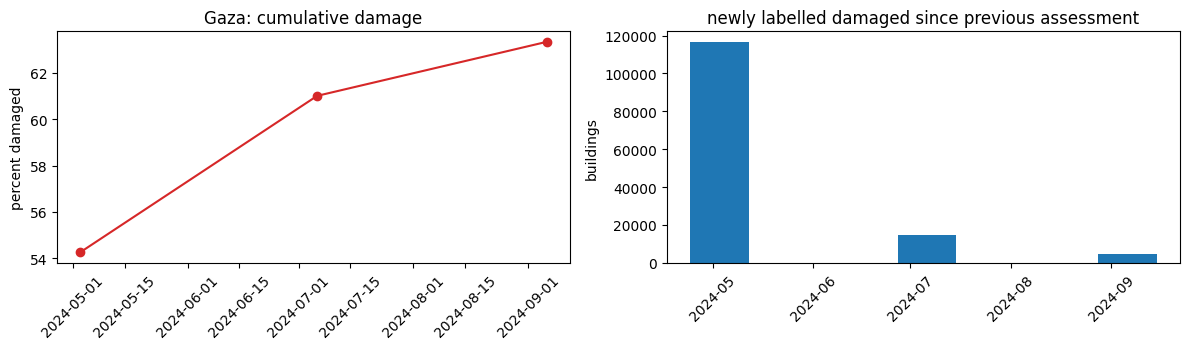

Prevalence climbs across the three assessments, which is the argument for fitting the decision threshold on SEVERAL dates in notebook 2: a threshold calibrated to one date's prevalence is systematically wrong for the others.


In [13]:
# Damage over time. Left: the cumulative share. Right: buildings newly
# labelled damaged since the previous assessment - which is where the new
# information in each date actually sits.
x = pd.to_datetime(dates)
new = np.diff(summary["damaged"].to_numpy(), prepend=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(x, summary["damaged %"], marker="o", color="C3")
ax[0].set_ylabel("percent damaged")
ax[0].set_title(f"{CITY}: cumulative damage")
ax[1].bar(x, new, width=18, color="C0")
ax[1].set_ylabel("buildings")
ax[1].set_title("newly labelled damaged since previous assessment")
for a in ax:
    a.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Prevalence climbs across the three assessments, which is the argument "
      "for fitting the decision threshold on SEVERAL dates in notebook 2: a "
      "threshold calibrated to one date's prevalence is systematically wrong "
      "for the others.")

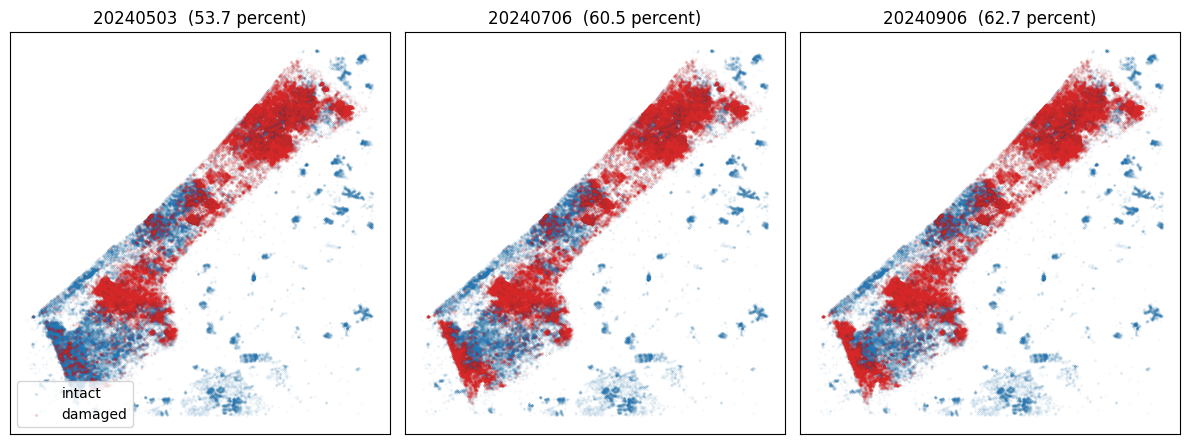

In [22]:
# Where the damage is, at each assessment date. It is clearly clustered,
# which is the argument for both the latitude-band splits (no leakage between
# train and test) and the spatial smoothing (use the clustering at prediction
# time). Only coordinates and labels are read here, never pixels.
tab = d["table"]
fig, axes = plt.subplots(1, len(dates), figsize=(4 * len(dates), 6))
axes = np.atleast_1d(axes)
for ax, dt in zip(axes, dates):
    y = tab[f"class_{dt}"].to_numpy(int)
    lat, lon = d["lat"], d["lon"]
    ax.scatter(lon[y == 0], lat[y == 0], s=0.05, alpha=0.15, color="C0", label="intact")
    ax.scatter(lon[y == 1], lat[y == 1], s=0.05, alpha=0.15, color="C3", label="damaged")
    ax.set_title(f"{dt}  ({y.mean() * 100:.1f} percent)")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(markerscale=6, loc="lower left")
plt.tight_layout()
plt.show()

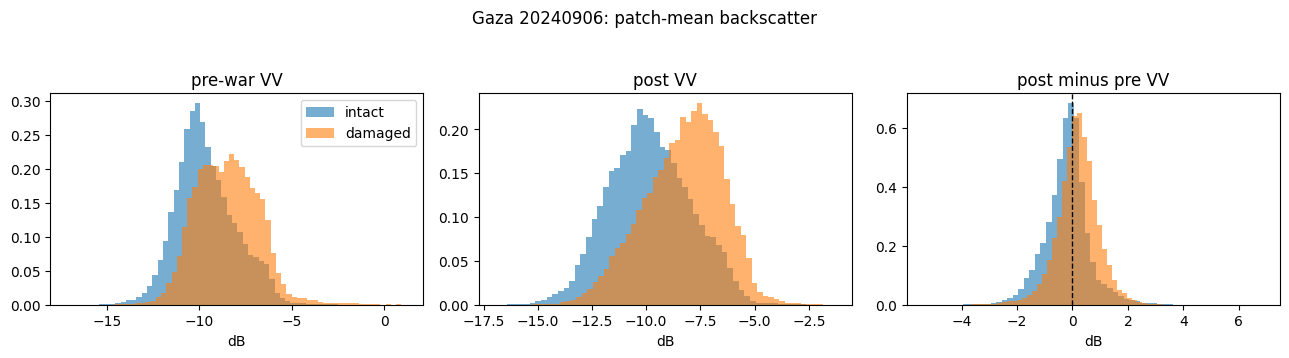

mean post-minus-pre, intact:  -0.20 dB
mean post-minus-pre, damaged: +0.19 dB
The classes overlap heavily, which is exactly why we hand a CNN the whole patch instead of a single summary number.


In [15]:
# The actual signal. A damaged building should look different AFTER the war
# relative to its OWN pre-war baseline, so the informative quantity is the
# post-minus-pre difference rather than either level alone. Decibels,
# averaged over each patch.
last = dates[-1]
ok = usable_mask(d, last)
y = tab[f"class_{last}"].to_numpy(int)[ok]

pi = d["pre_channel_names"].index("s1_pre_VV")
qi = d["post_channel_names"].index("s1_post_VV")
post_arr, _ = post_arrays(d, last)

# reading one channel of a memory map pulls only that channel off disk
pre_vv = d["pre"][ok, pi].mean(axis=(1, 2)).astype(np.float32)
post_vv = post_arr[ok, qi].mean(axis=(1, 2)).astype(np.float32)
diff = post_vv - pre_vv

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a, (v, name) in zip(ax, [(pre_vv, "pre-war VV"), (post_vv, "post VV"),
                             (diff, "post minus pre VV")]):
    a.hist(v[y == 0], bins=60, alpha=0.6, density=True, label="intact")
    a.hist(v[y == 1], bins=60, alpha=0.6, density=True, label="damaged")
    a.set_xlabel("dB")
    a.set_title(name)
ax[2].axvline(0, color="k", ls="--", lw=1)
ax[0].legend()
plt.suptitle(f"{CITY} {last}: patch-mean backscatter", y=1.04)
plt.tight_layout()
plt.show()

print(f"mean post-minus-pre, intact:  {diff[y == 0].mean():+.2f} dB")
print(f"mean post-minus-pre, damaged: {diff[y == 1].mean():+.2f} dB")
print("The classes overlap heavily, which is exactly why we hand a CNN the "
      "whole patch instead of a single summary number.")

### Does the temporal series carry anything?

Worth checking **before** spending training time on it. This runs no model at
all: it just takes the same patch-mean ΔVV statistic across the offset dates
and asks whether damaged and intact buildings separate more as time passes.

What the design predicts, if it is going to work:

* the gap between the two curves should **widen** from the earliest offset to
  the latest, because buildings labelled damaged in May were mostly already
  damaged in April and stay damaged in June;
* the intact curve should be roughly **flat**, since nothing happened to those
  buildings.

If instead both curves are flat and parallel, the offsets carry no
information beyond the labelled date, and the temporal features in notebook 2
will end up with near-zero importance. That is a legitimate finding — better
to see it here than after a training run.

 offset     date      n  intact  damaged    gap
    -24 20240409 213298  -0.065    0.195 -0.260
    -12 20240421 215023   0.642    0.809 -0.166
      0 20240503 214576   0.457    0.651 -0.195
     12 20240515 209900  -0.268    0.047 -0.315
     24 20240527 207284  -0.203    0.123 -0.326


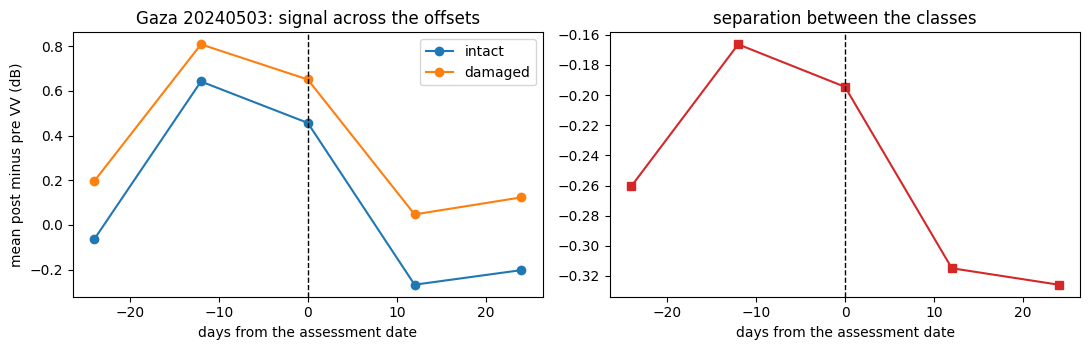


separation changes by -0.065 dB from the first offset to the last. Positive means damaged buildings drift further from intact ones over the window, which is the persistence the temporal features are meant to pick up.


In [16]:
def temporal_signal(city, date, channel="VV"):
    """Patch-mean post-minus-pre at every offset, split by the date's label."""
    d = load_city(city)
    tab = d["table"]
    pi = d["pre_channel_names"].index(f"s1_pre_{channel}")
    qi = d["post_channel_names"].index(f"s1_post_{channel}")
    win = temporal_window_days()

    # the pre-war baseline is the same at every offset, so read it once
    pre_mean = np.full(len(tab), np.nan, np.float32)
    pv = d["pre_valid"]
    pre_mean[pv] = d["pre"][pv, pi].mean(axis=(1, 2)).astype(np.float32)

    rows = []
    for off, od in offset_dates(date).items():
        wd = None if off == 0 else win
        try:
            arr, _ = post_arrays(d, od, wd)
        except FileNotFoundError:
            print(f"  {od} not cut, skipping")
            continue
        ok = usable_mask(d, od, wd)
        y = tab[f"class_{date}"].to_numpy(int)[ok]
        dv = (arr[ok, qi].mean(axis=(1, 2)).astype(np.float32) - pre_mean[ok])
        rows.append({"offset": off, "date": od, "n": int(ok.sum()),
                     "intact": float(dv[y == 0].mean()),
                     "damaged": float(dv[y == 1].mean())})
    df = pd.DataFrame(rows).sort_values("offset")
    df["gap"] = df["intact"] - df["damaged"]
    return df


sig = temporal_signal(CITY, dates[0])
print(sig.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(sig["offset"], sig["intact"], marker="o", label="intact")
ax[0].plot(sig["offset"], sig["damaged"], marker="o", label="damaged")
ax[0].axvline(0, color="k", ls="--", lw=1)
ax[0].set_xlabel("days from the assessment date")
ax[0].set_ylabel("mean post minus pre VV (dB)")
ax[0].set_title(f"{CITY} {dates[0]}: signal across the offsets")
ax[0].legend()
ax[1].plot(sig["offset"], sig["gap"], marker="s", color="C3")
ax[1].axvline(0, color="k", ls="--", lw=1)
ax[1].set_xlabel("days from the assessment date")
ax[1].set_title("separation between the classes")
plt.tight_layout()
plt.show()

trend = sig["gap"].iloc[-1] - sig["gap"].iloc[0]
print(f"\nseparation changes by {trend:+.3f} dB from the first offset to the "
      f"last. Positive means damaged buildings drift further from intact ones "
      f"over the window, which is the persistence the temporal features are "
      f"meant to pick up.")

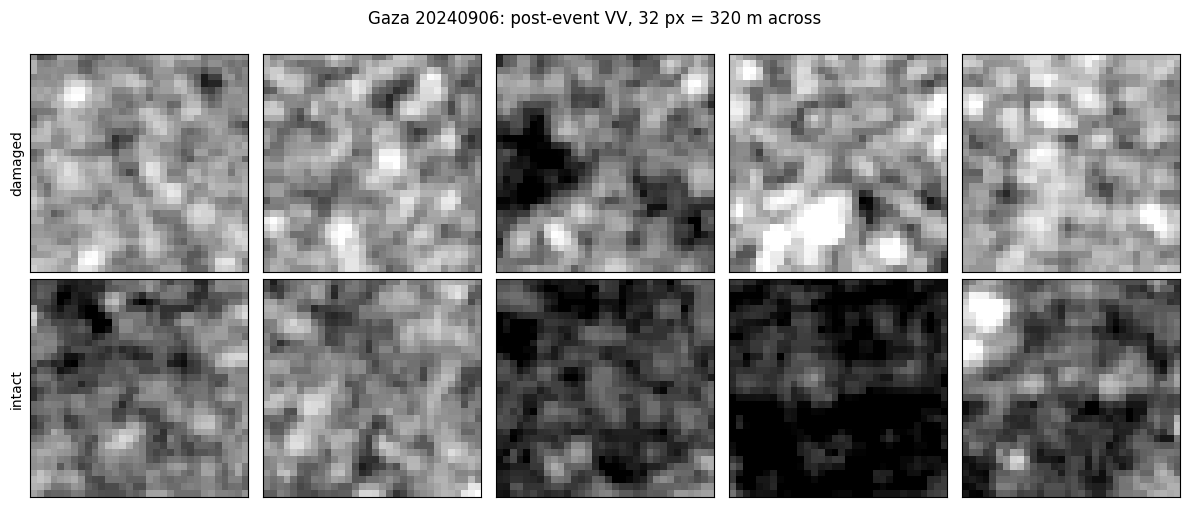

In [17]:
# Example patches: post-event VV for damaged and intact buildings, on a
# shared colour scale so they are comparable.
rng = np.random.default_rng(0)
idx = np.where(ok)[0]
dmg = rng.choice(idx[y == 1], 5, replace=False)
intact = rng.choice(idx[y == 0], 5, replace=False)
sample = np.asarray(post_arr[:5000, qi]).astype(np.float32)
vmin, vmax = np.percentile(sample, [2, 98])

fig, axes = plt.subplots(2, 5, figsize=(12, 5.2))
for row, (sel, name) in enumerate([(dmg, "damaged"), (intact, "intact")]):
    for col, j in enumerate(sel):
        axes[row, col].imshow(np.asarray(post_arr[j, qi]).astype(np.float32),
                              cmap="gray", vmin=vmin, vmax=vmax)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(name)
fig.suptitle(f"{CITY} {last}: post-event VV, "
             f"{PREP['patch_size']} px = {PREP['patch_size'] * 10} m across")
plt.tight_layout()
plt.show()

In [18]:
# Label quality, using the extra columns notebook 0 carried through.
g = d["table"]
sev = f"severity_{last}"
if sev in g.columns and g[sev].notna().any():
    print("UNOSAT severity of damaged buildings (1 = most severe):")
    print(g[sev].value_counts().sort_index().to_string())

# Do bigger buildings get labelled damaged more often? If strongly so, size
# alone carries label information, and the model could lean on patch texture
# that reflects size rather than damage.
if "area" in g.columns:
    by_size = (g.groupby(pd.qcut(g["area"], 5, duplicates="drop"), observed=True)
                 [f"class_{last}"].agg(["mean", "size"]))
    by_size["mean"] = (by_size["mean"] * 100).round(1)
    print("\ndamaged percent by building-size quintile:")
    print(by_size.rename(columns={"mean": "damaged %", "size": "n"}).to_string())

UNOSAT severity of damaged buildings (1 = most severe):
severity_20240906
1.0     56290
2.0     19135
3.0     46481
4.0     11470
6.0         8
11.0     3587

damaged percent by building-size quintile:
                     damaged %      n
area                                 
(50.009, 91.74]           55.5  43730
(91.74, 138.92]           64.8  43712
(138.92, 183.95]          67.8  43719
(183.95, 278.26]          68.5  43713
(278.26, 105650.37]       56.7  43717


Gaza_20240503_1_footprints.csv: 228,730 buildings, 57.49 percent damaged


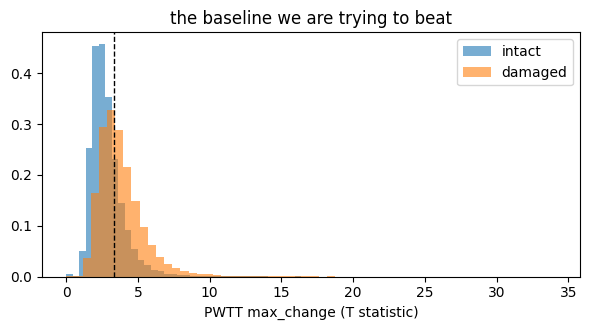

In [19]:
# The PWTT baseline. Our own label files have max_change empty, so this reads
# the published benchmark file directly - enough to see how separable the
# statistic is on its own. The dashed line is its published threshold of 3.3.
bench = sorted(glob.glob(os.path.join(PWTT_DIR, f"{CITY}_*_footprints.csv")))
if not bench:
    print(f"no benchmark file for {CITY} in {PWTT_DIR}, skipping")
else:
    b = pd.read_csv(bench[-1], usecols=["class", "max_change"], low_memory=False)
    print(f"{os.path.basename(bench[-1])}: {len(b):,} buildings, "
          f"{b['class'].mean() * 100:.2f} percent damaged")
    plt.figure(figsize=(6, 3.4))
    plt.hist(b.loc[b["class"] == 0, "max_change"], bins=60, alpha=0.6,
             density=True, label="intact")
    plt.hist(b.loc[b["class"] == 1, "max_change"], bins=60, alpha=0.6,
             density=True, label="damaged")
    plt.axvline(3.3, color="k", ls="--", lw=1)
    plt.xlabel("PWTT max_change (T statistic)")
    plt.title("the baseline we are trying to beat")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. The holdout cities

Raqqa, Mosul, Chernihiv and Rubizhne are `role: "holdout"`: reserved for the
final evaluation, and absent from every part of notebook 2's split —
including its `test` part, which is Gaza's own southern band and measures
something different (unseen ground, familiar city). This section looks at
them **completely** anyway, alongside Gaza, because knowing what the holdout
set contains before you run against it is worth more than strict blindness
would be. Nothing here fits anything.

The honest caveat, stated once and then dropped: a design choice made
*because* of a number below is a soft leak, and the final test numbers are
weaker for it. Reading these is fine; tuning against them is not.

**What is actually worth looking for**, in rough order of how much it should
change your expectations for the final test:

1. **Does the ΔVV signal separate the classes at all?** Gaza's damaged and
   intact buildings differ by a fraction of a dB in patch-mean backscatter,
   and heavily overlap. If a test city shows *no* separation, a Gaza-trained
   CNN has nothing to latch onto there and a poor score says more about the
   imagery than the model.
2. **How different is the prevalence?** Gaza runs 54–63 percent damaged. A
   city at 10 percent is a different problem: the decision threshold fitted
   on Gaza's validation band will be badly miscalibrated, which is an
   argument for reporting threshold-free metrics (AUC, average precision)
   alongside F1.
3. **How different are the buildings?** Mosul's dense low-rise Old City, the
   Soviet-era apartment blocks of Rubizhne and Chernihiv, and Gaza's
   mid-rise concrete are genuinely different scattering targets at 10 m.
4. **Sanity.** A city that silently produced zero usable patches, or a
   damaged share of 0 or 100 percent, is a pipeline bug, not a finding.

In [ ]:
# One row per city and date: size, prevalence, buildings, and the patch-mean
# ΔVV separation between damaged and intact. Everything is computed the same
# way for every city, so the rows are directly comparable to Gaza's.


def patch_mean_delta(d, date, channel="VV"):
    """(delta VV per building, label, usable mask) for one city and date.

    Post minus the city's OWN pre-war baseline, so each city is compared
    against itself rather than against an absolute backscatter level.
    """
    pi = d["pre_channel_names"].index(f"s1_pre_{channel}")
    qi = d["post_channel_names"].index(f"s1_post_{channel}")
    arr, _ = post_arrays(d, date)
    ok = usable_mask(d, date)
    pre = d["pre"][ok, pi].mean(axis=(1, 2)).astype(np.float32)
    post = arr[ok, qi].mean(axis=(1, 2)).astype(np.float32)
    y = d["table"][f"class_{date}"].to_numpy(int)[ok]
    return post - pre, y, ok


def city_profile(city):
    """Comparable summary rows for every labelled date of one city."""
    d = load_city(city)
    tab = d["table"]
    rows = []
    for date in CITY_REGISTRY[city]["label_dates"]:
        diff, y, ok = patch_mean_delta(d, date)
        area = tab.loc[ok, "area"] if "area" in tab.columns else pd.Series(dtype=float)
        # Cohen's d on the patch-mean delta: a scale-free read on how far
        # apart the two classes sit, comparable across cities
        s = np.sqrt(((y == 1).sum() * diff[y == 1].var()
                     + (y == 0).sum() * diff[y == 0].var())
                    / max(len(y), 1)) if 0 < y.sum() < len(y) else np.nan
        rows.append({
            "city": city,
            "role": city_role(city),
            "date": date,
            "buildings": int(ok.sum()),
            "damaged %": round(100 * y.mean(), 2) if len(y) else np.nan,
            "median area m2": round(float(area.median()), 1) if len(area) else np.nan,
            "dVV intact": round(float(diff[y == 0].mean()), 3) if (y == 0).any() else np.nan,
            "dVV damaged": round(float(diff[y == 1].mean()), 3) if (y == 1).any() else np.nan,
            "separation dB": round(float(diff[y == 1].mean() - diff[y == 0].mean()), 3)
                              if 0 < y.sum() < len(y) else np.nan,
            "cohen d": round(float((diff[y == 1].mean() - diff[y == 0].mean()) / s), 3)
                        if s and np.isfinite(s) and s > 0 else np.nan,
        })
    return rows


profile_rows, unavailable = [], {}
for city in CITY_REGISTRY:
    try:
        profile_rows += city_profile(city)
    except (FileNotFoundError, KeyError) as e:
        unavailable[city] = f"{type(e).__name__}: {e}"

profiles = pd.DataFrame(profile_rows)
print(profiles.to_string(index=False))

if unavailable:
    print("\nnot preprocessed yet, so not shown above:")
    for city, why in unavailable.items():
        print(f"  {city}: {why}")

print("\n'separation dB' is damaged minus intact, so NEGATIVE is the expected "
      "direction: destruction usually lowers patch-mean backscatter. "
      "'cohen d' puts that difference in units of its own spread, which is "
      "what makes it comparable across cities with different speckle levels. "
      "Gaza's value is the reference - a test city near zero means the signal "
      "the CNN learned in Gaza is simply not present there.")

In [ ]:
# Where the damage sits in each city, at its newest assessment. Each panel is
# its own extent - these are cities of very different sizes, so a shared axis
# would render the small ones as dots. Coordinates and labels only, no pixels.
shown = [c for c in CITY_REGISTRY if c not in unavailable]

fig, axes = plt.subplots(1, len(shown), figsize=(4.2 * len(shown), 4.6))
axes = np.atleast_1d(axes)
for ax, city in zip(axes, shown):
    dd = load_city(city)
    last_d = CITY_REGISTRY[city]["label_dates"][-1]
    yy = dd["table"][f"class_{last_d}"].to_numpy(int)
    ax.scatter(dd["lon"][yy == 0], dd["lat"][yy == 0], s=0.05, alpha=0.15,
               color="C0", label="intact")
    ax.scatter(dd["lon"][yy == 1], dd["lat"][yy == 1], s=0.05, alpha=0.15,
               color="C3", label="damaged")
    ax.set_title(f"{city} [{city_role(city)}]\n{last_d}  "
                 f"({yy.mean() * 100:.1f}% damaged, {len(yy):,} bldgs)",
                 fontsize=9)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(markerscale=6, loc="lower left", fontsize=7)
plt.suptitle("Damage footprint by city, newest assessment", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# The transferability question, in one figure: does ΔVV separate damaged from
# intact in each city the way it does in Gaza? Same statistic, same axes, one
# panel per city. Where the two histograms sit on top of each other, the
# CNN's input carries no class information at that city.
fig, axes = plt.subplots(1, len(shown), figsize=(3.6 * len(shown), 3.2),
                         sharex=True)
axes = np.atleast_1d(axes)
for ax, city in zip(axes, shown):
    dd = load_city(city)
    last_d = CITY_REGISTRY[city]["label_dates"][-1]
    diff, yy, _ = patch_mean_delta(dd, last_d)
    ax.hist(diff[yy == 0], bins=60, alpha=0.6, density=True, label="intact")
    ax.hist(diff[yy == 1], bins=60, alpha=0.6, density=True, label="damaged")
    ax.axvline(0, color="k", ls="--", lw=1)
    sep = diff[yy == 1].mean() - diff[yy == 0].mean()
    ax.set_title(f"{city} {last_d}\nseparation {sep:+.2f} dB", fontsize=9)
    ax.set_xlabel("post minus pre VV (dB)")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=7)
plt.xlim(-8, 8)
plt.suptitle("Patch-mean ΔVV: does the Gaza signal exist elsewhere?", y=1.04)
plt.tight_layout()
plt.show()

# Building stock differs between cities, and that alone changes how a fixed
# 32 px patch relates to a building. Worth seeing next to the signal above.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for city in shown:
    dd = load_city(city)
    if "area" not in dd["table"].columns:
        continue
    a = dd["table"]["area"].to_numpy(float)
    ax[0].hist(np.log10(a[a > 0]), bins=60, density=True, histtype="step",
               lw=1.6, label=f"{city} (med {np.median(a):.0f} m2)")
    last_d = CITY_REGISTRY[city]["label_dates"][-1]
    yy = dd["table"][f"class_{last_d}"].to_numpy(int)
    q = pd.qcut(dd["table"]["area"], 5, duplicates="drop", labels=False)
    ax[1].plot(range(len(np.unique(q[~pd.isna(q)]))),
               [100 * yy[q == k].mean() for k in sorted(pd.unique(q[~pd.isna(q)]))],
               marker="o", label=city)
ax[0].set_xlabel("log10 footprint area (m2)")
ax[0].set_ylabel("density")
ax[0].set_title("building size distribution")
ax[0].legend(fontsize=7)
ax[1].set_xlabel("building-size quintile (0 = smallest)")
ax[1].set_ylabel("percent damaged")
ax[1].set_title("does size predict damage, per city?")
ax[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

print("If the right-hand curve is steep for a city, footprint size alone "
      "carries label information there - and since patch texture reflects "
      "size, the CNN can pick that up as a shortcut. A curve that slopes "
      "differently in Gaza than in a test city is a concrete reason a "
      "Gaza-trained model might transfer poorly.")

In [ ]:
# What the CNN will actually be shown in each city: post-event VV patches,
# damaged on the left of each pair, intact on the right. Each city gets its
# own colour scale, since absolute backscatter levels differ between scenes
# and a shared scale would just show that offset rather than the texture.
rng = np.random.default_rng(0)
n_ex = 3

fig, axes = plt.subplots(len(shown), 2 * n_ex,
                         figsize=(1.5 * 2 * n_ex, 1.6 * len(shown)))
axes = np.atleast_2d(axes)
for r, city in enumerate(shown):
    dd = load_city(city)
    last_d = CITY_REGISTRY[city]["label_dates"][-1]
    qi_c = dd["post_channel_names"].index("s1_post_VV")
    arr, _ = post_arrays(dd, last_d)
    okc = usable_mask(dd, last_d)
    yc = dd["table"][f"class_{last_d}"].to_numpy(int)
    idx = np.where(okc)[0]
    dmg_i = idx[yc[idx] == 1]
    int_i = idx[yc[idx] == 0]

    scale = np.asarray(arr[idx[:3000], qi_c]).astype(np.float32)
    vmin, vmax = np.percentile(scale, [2, 98])

    picks = ([rng.choice(dmg_i, min(n_ex, len(dmg_i)), replace=False)]
             + [rng.choice(int_i, min(n_ex, len(int_i)), replace=False)])
    for c, j in enumerate(np.concatenate(picks)):
        axes[r, c].imshow(np.asarray(arr[j, qi_c]).astype(np.float32),
                          cmap="gray", vmin=vmin, vmax=vmax)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title("damaged" if c < n_ex else "intact", fontsize=8)
    axes[r, 0].set_ylabel(city, fontsize=8)

plt.suptitle(f"Post-event VV, {PREP['patch_size']} px = "
             f"{PREP['patch_size'] * 10} m across", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# A written read of the table above, so the conclusions are recorded next to
# the numbers rather than left to memory.
gaza_rows = profiles[profiles["city"] == "Gaza"]
if len(gaza_rows):
    g_sep = gaza_rows["separation dB"].mean()
    g_d = gaza_rows["cohen d"].mean()
    g_prev = gaza_rows["damaged %"].mean()
    print(f"Gaza reference: separation {g_sep:+.3f} dB, Cohen's d {g_d:+.3f}, "
          f"prevalence {g_prev:.1f} percent\n")

    for city in shown:
        if city == "Gaza":
            continue
        r = profiles[profiles["city"] == city].iloc[-1]
        notes = []
        if pd.notna(r["cohen d"]):
            ratio = abs(r["cohen d"]) / max(abs(g_d), 1e-9)
            if ratio < 0.33:
                notes.append(f"MUCH weaker signal ({ratio:.0%} of Gaza's d) - "
                             f"expect poor transfer here regardless of model")
            elif ratio < 0.7:
                notes.append(f"weaker signal ({ratio:.0%} of Gaza's d)")
            else:
                notes.append(f"comparable signal ({ratio:.0%} of Gaza's d)")
            if np.sign(r["cohen d"]) != np.sign(g_d):
                notes.append("signal points the OPPOSITE way to Gaza's, which "
                             "a Gaza-trained model will read backwards")
        gap = r["damaged %"] - g_prev
        if abs(gap) > 20:
            notes.append(f"prevalence {r['damaged %']:.1f}% vs Gaza's "
                         f"{g_prev:.1f}% - a Gaza-fitted threshold will be "
                         f"badly off; prefer AUC / average precision")
        if r["buildings"] < 5000:
            notes.append(f"only {r['buildings']:,} buildings, so its metrics "
                         f"carry wide error bars")
        print(f"{city} ({r['date']}):")
        for n in notes:
            print(f"   - {n}")
        print()
else:
    print("Gaza not preprocessed, so there is no reference row to compare to.")

## Done

On Drive now, for every city in `CITY_REGISTRY`:

* `rasters/` — one pre-war composite per city, one post composite per date
  (labelled and offset), plus `{city}_export.json` recording the pinned orbit
  and bounding box
* `processed/` — one `buildings.parquet` per city, one pre patch array, and
  one post patch array per date, each with its `valid` mask

`inventory_summary()` prints exactly what is present, so a later run can
confirm at a glance that Gaza is untouched and only new cities cost anything.

Continue with **notebook 2**. Two things there depend on what this notebook
just produced:

* **Multi-date validation and stacking.** Write `Gaza:0.33-0.42@*` in the
  split and it expands to one part per assessment date, so the decision
  threshold is fitted across dates rather than calibrated to one prevalence.
* **Temporal features.** The trained CNN is run over the offset dates and the
  resulting score series feeds the second-stage model. Nothing extra needs to
  be cut — the arrays are already here.

### Two rules for the splits in notebook 2

**Only Gaza may appear in any split part — including `test`.** Notebook 2's
`test` part is Gaza's southern band (`Gaza:0.00-0.33`), which is a different
thing from the holdout cities: it measures unseen ground in a city the model
knows. Raqqa, Mosul, Chernihiv and Rubizhne are `role: "holdout"` and belong
in *no* part of `CONFIG["split"]`. Guard it with

```python
from pipeline import check_split_holdout
assert not check_split_holdout(CONFIG["split"]), check_split_holdout(CONFIG["split"])
```

Section 6 above reads the holdout cities, but reading is all it does.

**Within Gaza, every band stays spatially disjoint.** Never hold out a *date*
instead of a band: almost every building damaged in May is still damaged in
September, so training on one date and testing on another would overlap
almost completely. That is why `train`, `stack`, `val` and `test` are four
non-overlapping latitude ranges, and why `stack` needs a band of its own —
the second stage must see CNN scores the CNN was not fitted on.

### What Section 6 said about the final test

Whatever the per-city numbers turned out to be, note the two failure modes
they predict, since neither is the model's fault and both will otherwise look
like one:

* a city whose ΔVV separation is near zero has no signal for the CNN to
  transfer, so a low score there measures the imagery, not the architecture;
* a city whose prevalence is far from Gaza's will be badly served by a
  Gaza-fitted decision threshold, so report AUC and average precision beside
  any F1.